# Word2Vec on Movie Review Sentiment Dataset

This notebook trains Word2Vec word embeddings from the `review` text in your movie sentiment dataset. The `sentiment` column is useful for later classification, but Word2Vec itself is trained on text only.

## 1. Import Libraries

In [3]:
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt

from gensim.models import Word2Vec
from gensim.utils import simple_preprocess
from sklearn.decomposition import PCA

## 2. Load the Dataset

In [4]:
dataset_path = Path("movie_reviews_sentiment.xlsx")

if not dataset_path.exists():
    dataset_path = Path("Word2vec") / "movie_reviews_sentiment.xlsx"

df = pd.read_excel(dataset_path)
df.head()

,review,sentiment
0,I was completely captivated from the opening s...,positive
1,This film exceeded every expectation I had. It...,positive
2,A profound failure of imagination. The screenp...,negative
3,Compulsively watchable and emotionally resonan...,positive
4,I struggled to stay awake through the second a...,negative


## 3. Check Dataset Structure

In [5]:
print("Shape:", df.shape)
print("Columns:", df.columns.tolist())
print("Missing values:")
print(df.isnull().sum())

df["sentiment"].value_counts()

Shape: (20000, 2)
Columns: ['review', 'sentiment']
Missing values:
review       0
sentiment    0
dtype: int64


sentiment
positive    10000
negative    10000
Name: count, dtype: int64

## 4. Prepare Reviews for Word2Vec

`simple_preprocess` lowercases text, removes punctuation, and tokenizes each review into words.

In [6]:
reviews = df["review"].dropna().astype(str)

tokenized_reviews = [simple_preprocess(review, deacc=True) for review in reviews]

print("Number of reviews:", len(tokenized_reviews))
print("First tokenized review:")
print(tokenized_reviews[0])

Number of reviews: 20000
First tokenized review:
['was', 'completely', 'captivated', 'from', 'the', 'opening', 'scene', 'it', 'film', 'that', 'rewards', 'repeat', 'viewings', 'layers', 'reveal', 'themselves', 'on', 'closer', 'inspection', 'the', 'screenplay', 'is', 'sharp', 'witty', 'and', 'never', 'condescending', 'to', 'its', 'audience', 'do', 'not', 'miss', 'this', 'one']


## 5. Train the Word2Vec Model

Important parameters:

- `vector_size`: number of dimensions in each word embedding
- `window`: how many nearby words Word2Vec looks at
- `min_count`: ignore words that appear fewer than this many times
- `sg=1`: skip-gram model; use `sg=0` for CBOW
- `epochs`: number of training passes over the dataset

In [7]:
w2v_model = Word2Vec(
    sentences=tokenized_reviews,
    vector_size=100,
    window=5,
    min_count=2,
    workers=4,
    sg=1,
    epochs=20,
    seed=42
)

print("Vocabulary size:", len(w2v_model.wv))

Vocabulary size: 1830


## 6. Get the Embedding Vector of a Word

In [8]:
word = "movie"

if word in w2v_model.wv:
    embedding = w2v_model.wv[word]
    print(f"Embedding shape for '{word}':", embedding.shape)
    print(embedding)
else:
    print(f"'{word}' is not in the vocabulary.")

Embedding shape for 'movie': (100,)
[ 0.27739725  0.09535892  0.7568236   0.18470421  0.11561229 -0.06400698
  0.10442804  1.1667764  -0.3991429   0.81480455 -0.51134276  0.06709883
  0.04864319  0.6054129  -0.21234013 -0.39267942 -1.0309198   0.26994357
  0.04250739  0.01260138 -1.3566777  -0.42961723 -0.43744397 -0.06565528
 -0.8232068   0.5310779   0.03934557 -0.17457107  0.58552593 -0.48408124
  0.3626264  -0.05112848  0.5865443   0.46452713 -0.58666664 -0.7930701
  0.40537813 -0.21469486  1.3014853  -0.28595006  0.24077947 -0.06692384
  0.1701438   0.254558   -0.16721632  0.28927863 -0.77310175  0.15794429
  0.6673612  -0.47001407 -0.03624007 -0.6288302   0.62553924  0.5772206
  0.651407    0.5516696   0.08640102 -0.45420042 -0.35436845  0.25205603
  0.59486103 -0.3930243  -0.68653846 -0.7372339   0.24479872  0.88822436
  0.17106262 -0.2629417  -0.15991393  0.47065884  0.1557534  -0.8999041
 -0.32930553  0.24607591 -0.39892694  0.88036215  0.6656799  -0.17868763
  0.35633788  0.25

## 7. Find Similar Words

In [9]:
query_words = ["good", "bad", "excellent", "boring", "acting", "story"]

for query_word in query_words:
    if query_word in w2v_model.wv:
        print(f"\nMost similar words to '{query_word}':")
        for similar_word, score in w2v_model.wv.most_similar(query_word, topn=10):
            print(f"{similar_word:15s} {score:.4f}")
    else:
        print(f"\n'{query_word}' is not in the vocabulary.")


Most similar words to 'good':
stonishingly    0.7849
goo             0.7665
astonishingly   0.7657
astonis         0.7616
shingly         0.7552
ishingly        0.7552
ood             0.7546
aston           0.7513
onishingly      0.7505
testament       0.7486

Most similar words to 'bad':
profoundly      0.7790
exist           0.6364
watching        0.6286
costs           0.6205
money           0.6166
tale            0.5992
studio          0.5877
demand          0.5872
refund          0.5854
should          0.5796

'excellent' is not in the vocabulary.

'boring' is not in the vocabulary.

'acting' is not in the vocabulary.

'story' is not in the vocabulary.


## 8. Create an Embedding Table

In [10]:
embedding_df = pd.DataFrame(
    w2v_model.wv.vectors,
    index=w2v_model.wv.index_to_key
)

embedding_df.head()

,0,1,2,3,4,5,6,7,8,9,...,90,91,92,93,94,95,96,97,98,99
the,-0.271955,0.290783,0.240577,0.047045,-0.230732,-0.194326,-0.423232,0.142590,-0.235499,-0.309048,...,-0.351929,0.407052,0.116139,0.015272,0.466897,-0.232521,-0.178384,0.218341,0.342137,0.024333
and,-0.256593,-0.041405,-0.517902,-0.117784,0.269545,0.085546,0.145826,0.023271,0.234517,0.086916,...,-0.022629,-0.250151,-0.227471,-0.169072,0.185936,-0.585595,-0.058710,0.342439,-0.575485,0.104648
is,0.143771,0.322169,-0.332728,-0.219177,-0.112246,-0.117430,-0.034821,-0.095277,-0.751198,0.216436,...,-0.419062,0.289883,0.139224,-0.787272,0.091303,0.064484,0.696922,0.140456,-0.350428,-0.393907
of,-0.099828,-0.050289,0.248528,0.034713,-0.566500,0.131261,-0.185378,-0.067231,-0.369314,0.198216,...,-1.057196,0.073522,-0.189858,-0.372334,0.512402,0.692769,0.224835,0.036081,-0.119926,0.158565
to,0.361062,0.536611,0.066352,0.531147,0.124878,0.261793,0.176031,-0.252158,0.471173,-0.534983,...,-0.185085,0.391891,0.088789,0.331615,-0.060632,-0.170787,-0.915841,-0.003944,0.542963,-0.124854


## 9. Visualize Some Word Embeddings with PCA

Word2Vec vectors have 100 dimensions here. PCA reduces them to 2 dimensions so we can plot them.

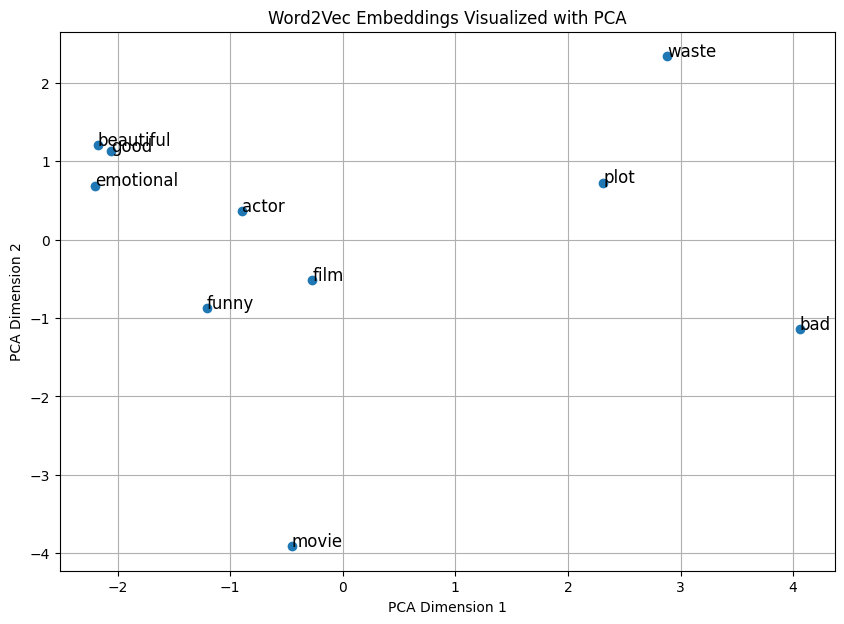

In [11]:
words_to_plot = [
    "good", "great", "excellent", "bad", "terrible", "boring",
    "movie", "film", "story", "plot", "acting", "actor",
    "funny", "emotional", "beautiful", "waste"
]

words_to_plot = [word for word in words_to_plot if word in w2v_model.wv]
vectors_to_plot = [w2v_model.wv[word] for word in words_to_plot]

pca = PCA(n_components=2, random_state=42)
reduced_vectors = pca.fit_transform(vectors_to_plot)

plt.figure(figsize=(10, 7))
plt.scatter(reduced_vectors[:, 0], reduced_vectors[:, 1])

for word, (x, y) in zip(words_to_plot, reduced_vectors):
    plt.annotate(word, (x, y), fontsize=12)

plt.title("Word2Vec Embeddings Visualized with PCA")
plt.xlabel("PCA Dimension 1")
plt.ylabel("PCA Dimension 2")
plt.grid(True)
plt.show()

## 10. Save the Model and Embeddings

In [12]:
output_dir = dataset_path.parent
model_path = output_dir / "movie_review_word2vec.model"
embeddings_path = output_dir / "movie_review_word_embeddings.csv"

w2v_model.save(str(model_path))
embedding_df.to_csv(embeddings_path)

print("Saved model to:", model_path)
print("Saved embeddings to:", embeddings_path)

Saved model to: movie_review_word2vec.model
Saved embeddings to: movie_review_word_embeddings.csv


## 11. Load the Saved Model Later

In [13]:
loaded_model = Word2Vec.load(str(model_path))

loaded_model.wv.most_similar("movie", topn=5)

[('bloated', 0.6696580648422241),
 ('incoherent', 0.6688315868377686),
 ('mess', 0.6587685942649841),
 ('comprehension', 0.6176564693450928),
 ('my', 0.5962502956390381)]

In [ ]:
w2v_model.wv.most_similar("movie", topn=5)

[('bloated', 0.6696580648422241),
 ('incoherent', 0.6688315868377686),
 ('mess', 0.6587685942649841),
 ('comprehension', 0.6176564693450928),
 ('my', 0.5962502956390381)]

In [17]:
#w2v_model.wv.most_similar("cricket", topn=5)

In [26]:
print(w2v_model.wv.similarity("good", "good"))
print(w2v_model.wv.similarity("good", "bad"))
print(w2v_model.wv.similarity("movie", "film"))
print(w2v_model.wv.similarity("good", "movie"))

1.0
0.1607519
0.17956829
0.17780402


In [28]:
vec=w2v_model.wv["movie"]-w2v_model.wv["film"]+w2v_model.wv["good"]-w2v_model.wv["bad"]
w2v_model.wv.most_similar([vec], topn=5)

[('good', 0.5197080373764038),
 ('movie', 0.3873744010925293),
 ('astonishingly', 0.36329296231269836),
 ('testament', 0.356263667345047),
 ('aston', 0.3542402386665344)]